Name: Prashna Shrestha
group: L6CG2
std no: 2408642



Simple CNN Implementation using keras.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9603 - loss: 0.1295 - val_accuracy: 0.9817 - val_loss: 0.0576
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9869 - loss: 0.0421 - val_accuracy: 0.9882 - val_loss: 0.0351
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9908 - loss: 0.0294 - val_accuracy: 0.9902 - val_loss: 0.0305
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9933 - loss: 0.0209 - val_accuracy: 0.9901 - val_loss: 0.0290
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9949 - loss: 0.0154 - val_accuracy: 0.9909 - val_loss: 0.0307
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9909 - loss: 0.0307
Test accuracy: 0.9909
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


Task 1: Loading data

In [20]:
import zipfile

zip_path = "/content/drive/MyDrive/Ai and machine learning/week5/Copy of FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [28]:
train_dir = "/content/dataset/FruitinAmazon/train"

# Check structure
print(os.listdir("dataset"))
print(os.listdir(train_dir))

['FruitinAmazon']
['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']
['FruitinAmazon']


Checking for corrupted images

In [30]:
from PIL import Image
import os

train_dir =  "/content/dataset/FruitinAmazon/train"

corrupted_images = []

for root, dirs, files in os.walk(train_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            img = Image.open(file_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(file_path)
            os.remove(file_path)
            print(f"Removed corrupted image: {file_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


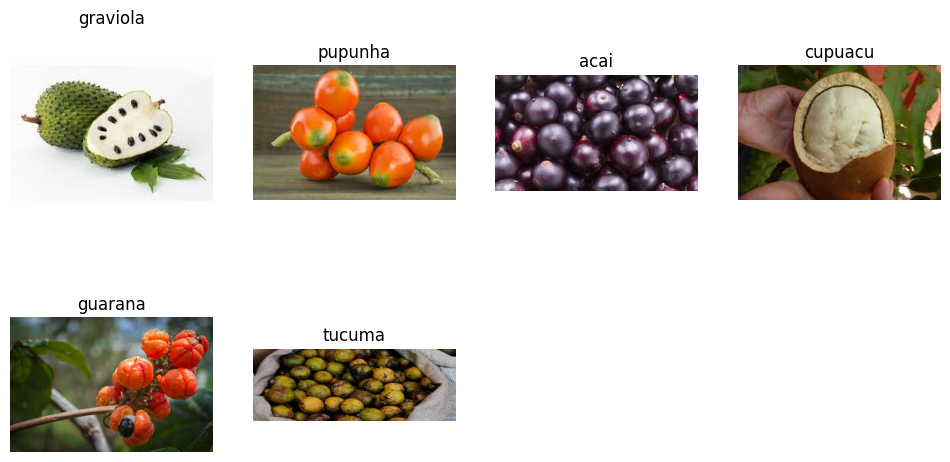

In [29]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/dataset/FruitinAmazon/train"

classes = os.listdir(train_dir)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)

    # Skip if not a directory
    if not os.path.isdir(class_path):
        continue

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Task 2: Loading and processing data

In [35]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_dir = "/content/dataset/FruitinAmazon/train"

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)


class_names = train_ds.class_names
num_classes = len(class_names)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Task 3 : Building the CNN model

In [37]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compiling Model

In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Training model

In [39]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.1655 - loss: 1.9214
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 674ms/step - accuracy: 0.1528 - loss: 2.0141 - val_accuracy: 0.8333 - val_loss: 1.6286
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.2199 - loss: 1.9179
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.2222 - loss: 1.8549 - val_accuracy: 0.7778 - val_loss: 1.5109
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.3495 - loss: 1.6273
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.3611 - loss: 1.6020 - val_accuracy: 0.6111 - val_loss: 1.4367
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.3281 - loss: 1.5463
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 0.3750 - loss: 1.5064 - val_accuracy: 0.6111 - val_loss: 1.2943
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.4826 - loss: 1.305


Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 537ms/step - accuracy: 0.8611 - loss: 0.6200 - val_accuracy: 0.9444 - val_loss: 0.4084
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9149 - loss: 0.4340
Epoch 9: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.9167 - loss: 0.4430 - val_accuracy: 0.5556 - val_loss: 1.0806
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9294 - loss: 0.3619
Epoch 10: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.9444 - loss: 0.3357 - val_accuracy: 0.8333 - val_loss: 0.4524
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9797 - loss: 0.1629
Epoch 11: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - accuracy: 0.9861 - loss: 0.1432 - val_accuracy: 0.8333 - val_loss: 0.9032
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9595 - loss: 

Task 6: Evaluating the model

In [41]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9444 - loss: 0.4084
Test Accuracy: 0.9444444179534912
Test Loss: 0.40835386514663696


Task 7: Saving and loading model

In [42]:
# Save model
model.save("final_model.h5")

# Load model
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.h5")

# Evaluate again
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9444 - loss: 0.4084
Loaded Model Accuracy: 0.9444444179534912


Task 8: Predicting and classification report

In [45]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in train_ds:
    predictions = loaded_model.predict(images)
    preds = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Unique y_true:", set(y_true))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Unique y_true: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}
              precision    recall  f1-score   support

        acai       0.88      1.00      0.93        14
     cupuacu       0.92      0.85      0.88        13
    graviola       1.00      0.83      0.91        12
     guarana       1.00      0.70      0.82        10
     pupunha       1.00      0.91      0.95        11
      tucuma       0.71      1.00      0.83        12

    accuracy                           0.89        72
   macro avg       0.92      0.88      0.89        72
weighted avg       0.91      0.89      0.89        72



The above result shows an over all accuracy of 89% including all the six fruit classes.